In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, random, torch
import torch.nn as nn
from tqdm import tqdm
from pathlib import PureWindowsPath
from monai.transforms import LoadImage
from monai.data import Dataset, DataLoader
from monai.transforms import (Compose,LoadImaged,ScaleIntensityd, ScaleIntensityRanged, Resized)
from monai.networks.nets import resnet10
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch.nn.functional as F
from monai.data import MetaTensor

import sys
sys.path.append("/projects/net_contrast_classification/contrast_phase")

# from Radiomics.models_pipe import train_tree_models
# from Radiomics.data_preprocessing import radiomics_load, train_test_split, preprocess_train, preprocess_test
# import segmentation_models_pytorch as smp
# from monai.transforms import (Compose, LoadImage, Spacing, Orientationd, Spacingd, CropForegroundd, ResizeWithPadOrCrop, ScaleIntensityRange, Resize, RandFlip, RandRotate90, RandGaussianNoise)

# Data Analysis

In [10]:
data_dir = Path("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv")

features_dir = Path("/projects/net_contrast_classification/contrast_phase/Radiomics/features")

radiomics = radiomics_load(data_dir, features_dir)

train_data, test_data = train_test_split(radiomics, test_size=0.3, grouping="SubjectKeyRadiology")

meta_cols = list(train_data.iloc[:, :5].columns)

train_pipeline = preprocess_train(train_data, meta_cols,NA_filter_threshold=0.2, pca_components=30)

train_processed = train_pipeline["data_processed"]
X_train_pca = train_pipeline["X_pca"]
test_processed, X_test_pca = preprocess_test(test_data, meta_cols,train_pipeline)

contrast_le = LabelEncoder()

X_train, y_train = train_processed.iloc[:, 4:], contrast_le.fit_transform(train_processed.contrast)
X_test, y_test = test_processed.iloc[:, 4:], contrast_le.fit_transform(test_processed.contrast)

print(f"Shape of train data: {X_train.shape}\nShape of train labels: {y_train.shape}")
print(f"Shape of test data: {X_test.shape}\nShape of test labels: {y_test.shape}")

models = train_tree_models(X_train, y_train)

Shape of train data: (5672, 212)
Shape of train labels: (5672,)
Shape of test data: (2661, 212)
Shape of test labels: (2661,)


In [11]:
GBT_model = models['GBT']

In [3]:

def data_load(dataset, sample = None):
    dataset['server_folder'] = dataset.exist_on_server.apply(lambda x: "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET" 
                                                             if pd.notna(x)  
                                                             else "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server")
    
    dataset = dataset[(dataset.contrast.isin(['Arterial', "Portal"]))
                & (dataset.is_liver_imaged == "Yes")
                & (dataset.phase_timing != '0.0')
                & (dataset.is_lesionfree == "No") # remove later
                ]
    
    dataset = dataset.sort_values(by=["SubjectKeyRadiology", "ExamDate", "contrast"], ascending=True)


    if not sample:
        files = [os.path.join(row['server_folder'], PureWindowsPath(row['MatchKey']).name) for _, row in dataset.iterrows()]
        organ_files = [f.replace(".nii.gz", ".organs.nii.gz") for f in files]
        seg_files = [f.replace(".nii.gz", ".seg.nii.gz") for f in files]
        labels = list(dataset.contrast)

    else:
        dataset['contrast_timing'] = (dataset["contrast"].str.cat(dataset["phase_timing"], sep=" "))
        dataset["contrast_timing"] = dataset["contrast_timing"].astype(str).str.strip()

        sampled_df = dataset.groupby('contrast_timing', group_keys=False).apply(lambda x: x.sample(n=min(len(x), sample), random_state=42))

        files = [os.path.join(row['server_folder'], PureWindowsPath(row['MatchKey']).name) for _, row in sampled_df.iterrows()]
        organ_files = [f.replace(".nii.gz", ".organs.nii.gz") for f in files]
        seg_files = [f.replace(".nii.gz", ".seg.nii.gz") for f in files]
        labels = list(sampled_df.contrast)



    return files, organ_files, seg_files, labels

In [4]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv")
data.is_lesionfree

0        No
1        No
2       Yes
3       Yes
4        No
       ... 
8729     No
8730    Yes
8731     No
8732    Yes
8733    Yes
Name: is_lesionfree, Length: 8734, dtype: str

In [5]:
data.iloc[8723:8725, :]

,NiiFile,SegNiiFile,Original File,Destination Folder,New File,SubjectKeyRadiology,ExamDate,file,is_liver_imaged,contrast,...,ImageOrientationPatientDICOM,ConversionSoftware,ConversionSoftwareVersion,BodyPartExamined,RawImage,SliceThickness,AcquisitionTime_sec,DICOM_phase,MatchKey,exist_on_server
8723,Z:\_archived\DICOM-batch3-kalina99\NET_5821_00...,Z:\_archived\DICOM-batch3-kalina99\NET_5821_00...,../DICOM-batch3\NKI-d23231-00-0887\20230830 CT...,DICOM-batch3-kalina99,NET_5821_0000.nii.gz,NKI-d23231-00-0887,2023-08-30,NET_5821_0000.nii.gz,Yes,Arterial,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,47716.7,Arterial,NKI-d23231-00-0887_20230830_kalina99_5821.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
8724,Z:\_archived\DICOM-batch3-kalina99\NET_5822_00...,Z:\_archived\DICOM-batch3-kalina99\NET_5822_00...,../DICOM-batch3\NKI-d23231-00-0887\20230830 CT...,DICOM-batch3-kalina99,NET_5822_0000.nii.gz,NKI-d23231-00-0887,2023-08-30,NET_5822_0000.nii.gz,Yes,Portal,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,47745.6,Portal,NKI-d23231-00-0887_20230830_kalina99_5822.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...


In [6]:
files, organ_files, seg_files, labels = data_load(data.iloc[8723:8725, :])

In [7]:
print(labels[0], files[0], organ_files[0], seg_files[0])
print(labels[1], files[1], organ_files[1], seg_files[1])

Arterial /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20230830_kalina99_5821.nii.gz /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20230830_kalina99_5821.organs.nii.gz /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20230830_kalina99_5821.seg.nii.gz
Portal /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20230830_kalina99_5822.nii.gz /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20230830_kalina99_5822.organs.nii.gz /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20230830_kalina99_5822.seg.nii.gz


In [8]:
def window_ct(img, center=50, width=150):
    low = center - width / 2
    high = center + width / 2
    return img.clip(low, high)

loader = LoadImage(image_only=True, ensure_channel_first=True)
image_a = loader(files[0])
seg_a = loader(seg_files[0])

image_p = loader(files[1])
seg_p = loader(seg_files[1])

In [9]:
loader.readers

[115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132
 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150
 151 152 153 154 155 156 157 158 159 160 161 162]


/tmp/ipykernel_784110/567553338.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  rgba_a[..., 3] = mask_a * 0.5


[114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131
 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149
 150 151 152 153 154 155 156 157 158 159 160 161 162]


/tmp/ipykernel_784110/567553338.py:36: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  rgba_p[..., 3] = mask_p * 0.5


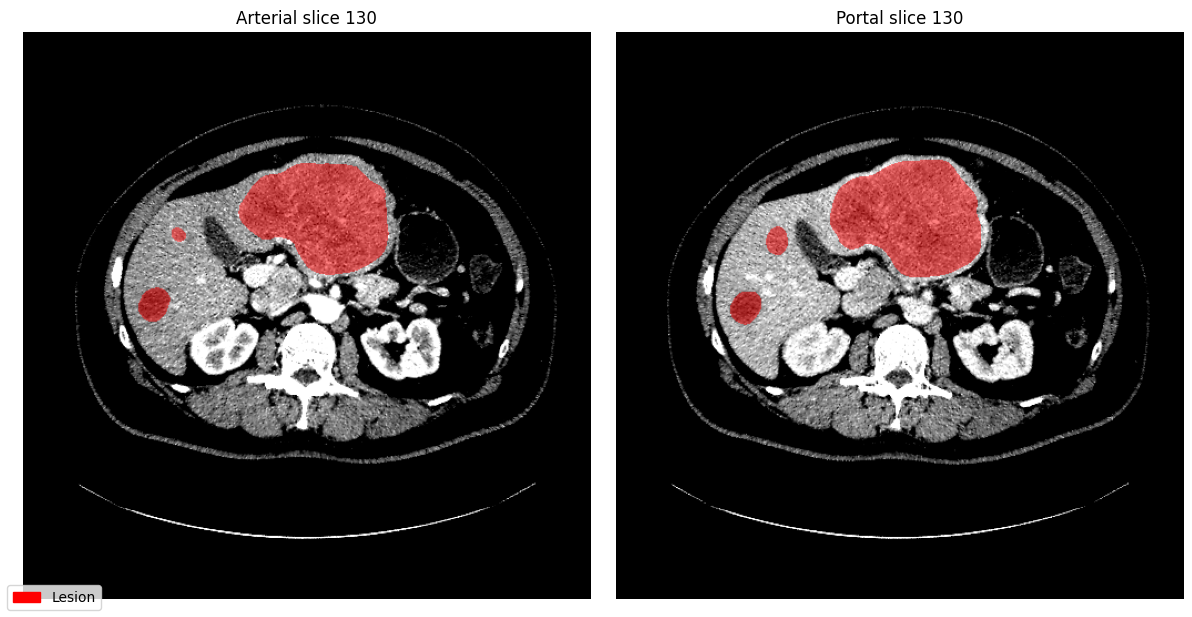

In [ ]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# -------------------------
# Arterial slice
# -------------------------
lesion_slices_a = np.where(seg_a[0].sum(axis=(0, 1)) > 0)[0]
print(lesion_slices_a)
slice_idx_a = lesion_slices_a[len(lesion_slices_a)//2]
slice_idx_a = 130
ct_slice_a = np.rot90(image_a[0, :, :, slice_idx_a], k=1)
mask_a = seg_a[0, :, :, slice_idx_a] > 0

axes[0].imshow(window_ct(ct_slice_a), cmap="gray")
rgba_a = np.zeros((*mask_a.shape, 4))
rgba_a[..., :3] = [1, 0, 0]
rgba_a[..., 3] = mask_a * 0.5
axes[0].imshow(np.rot90(rgba_a, k=1))
axes[0].set_title(f"{str.capitalize(labels[0])} slice {slice_idx_a}")
axes[0].axis("off")

# -------------------------
# Portal slice
# -------------------------
lesion_slices_p = np.where(seg_p[0].sum(axis=(0, 1)) > 0)[0]
print(lesion_slices_p)
slice_idx_p = lesion_slices_p[len(lesion_slices_p)//2]
slice_idx_p = 130
ct_slice_p = np.rot90(image_p[0, :, :, slice_idx_p], k=1)
mask_p = seg_p[0, :, :, slice_idx_p] > 0

axes[1].imshow(window_ct(ct_slice_p), cmap="gray")
rgba_p = np.zeros((*mask_p.shape, 4))
rgba_p[..., :3] = [1, 0, 0]
rgba_p[..., 3] = mask_p * 0.5
axes[1].imshow(np.rot90(rgba_p, k=1))
axes[1].set_title(f"{str.capitalize(labels[1])} slice {slice_idx_p}")
axes[1].axis("off")

# -------------------------
# Legend (shared)
# -------------------------
legend_patches = [Patch(color="red", label="Lesion")]
fig.legend(handles=legend_patches, loc="lower left", framealpha=0.8, fontsize=10)

plt.tight_layout()
plt.show()

# Preprocessing Pipe

In [2]:

def files_load(data_dir, sample = None):

    dataset = pd.read_csv(data_dir)

    dataset['server_folder'] = dataset.exist_on_server.apply(lambda x: "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET" 
                                                             if pd.notna(x)  
                                                             else "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server")
    
    dataset = dataset[(dataset.contrast.isin(['Arterial', "Portal"]))
                & (dataset.is_liver_imaged == "Yes")
                & (dataset.phase_timing != '0.0')
                & (dataset.is_lesionfree == "No") # remove later
                ]
    
    dataset = dataset.sort_values(by=["SubjectKeyRadiology", "ExamDate", "contrast"], ascending=True)

    if not sample:
        files = [os.path.join(row['server_folder'], PureWindowsPath(row['MatchKey']).name) for _, row in dataset.iterrows()]
        organ_files = [f.replace(".nii.gz", ".organs.nii.gz") for f in files]
        seg_files = [f.replace(".nii.gz", ".seg.nii.gz") for f in files]
        labels = dataset['contrast'].tolist()
        keys = dataset['MatchKey'].tolist()

    else:

        sampled_df = (
            dataset
            .groupby('contrast', group_keys=False)
            .sample(n=sample, replace=True, random_state=42)
            .reset_index(drop=True)
        )

        files = [os.path.join(row['server_folder'], PureWindowsPath(row['MatchKey']).name) for _, row in sampled_df.iterrows()]
        organ_files = [f.replace(".nii.gz", ".organs.nii.gz") for f in files]
        seg_files = [f.replace(".nii.gz", ".seg.nii.gz") for f in files]
        labels = sampled_df['contrast'].tolist()
        keys = sampled_df['MatchKey'].tolist()


    return keys, files, organ_files, seg_files, labels

In [3]:
data_dir = "/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv"
keys, image_files, organ_files, seg_files, labels = files_load(data_dir, sample = 1)

In [4]:
keys, image_files, organ_files, seg_files, labels

(['NKI-d23231-00-0448_20150818_kalina99_2955.nii.gz',
  'NKI-d23231-00-0276_20150216_kalina99_0864.nii.gz'],
 ['/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0448_20150818_kalina99_2955.nii.gz',
  '/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0276_20150216_kalina99_0864.nii.gz'],
 ['/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0448_20150818_kalina99_2955.organs.nii.gz',
  '/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0276_20150216_kalina99_0864.organs.nii.gz'],
 ['/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0448_20150818_kalina99_2955.seg.nii.gz',
  '/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0276_20150216_kalina99_0864.seg.nii.gz'],
 ['Arterial', 'Portal'])

In [5]:
from Radiomics.radiomics_pipeline import multi_channel
def data_load(image_files, organ_files, seg_files, labels, organ_ids, idx):
    
    loader = LoadImage(image_only=True, ensure_channel_first=True)
    
    image = loader(image_files[idx])
    lesions_raw = loader(seg_files[idx])
    organ_array, lesions = None, None
    label = labels[idx]

    if organ_ids is not None:
        try:
            organ_array_raw = loader(organ_files[idx])
            if organ_array_raw.ndim == 3:
                organ_array_raw = organ_array_raw.unsqueeze(0)

            if np.size(organ_array_raw) == 0:
                raise ValueError("Empty organ file")

            organ_array = multi_channel(organ_ids, organ_array_raw)
            # Convert to torch tensor
            organ_array = torch.from_numpy(organ_array.astype(np.float32))

            # Wrap as MetaTensor
            organ_array = MetaTensor(organ_array, affine=torch.eye(4))

        except Exception as e:
            print(f"Fallback: {e}")

    if lesions_raw is not None and np.size(lesions_raw) > 0:
        lesions = torch.from_numpy((lesions_raw > 0).astype(np.float32))
        if lesions.ndim == 3:  # add channel dim
            lesions = lesions.unsqueeze(0)
    else:
        lesions = None

    
    return image, organ_array, lesions, label

In [6]:
image, organ_array, lesions, label = data_load(image_files, organ_files, seg_files, labels, organ_ids=[5], idx=0)

torch.Size([1, 512, 512, 180])


torch.Size([1, 512, 512, 180])
torch.Size([1, 512, 512, 180])


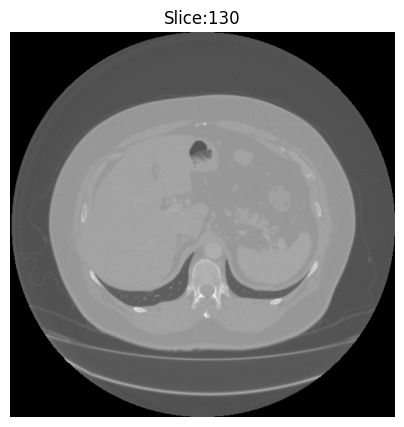

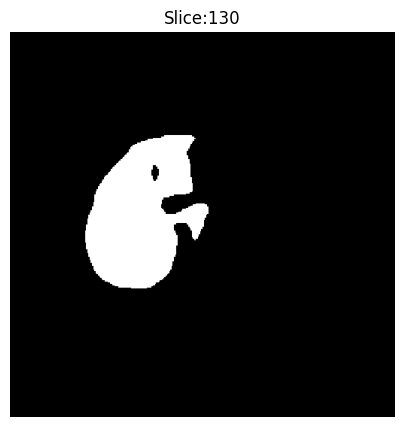

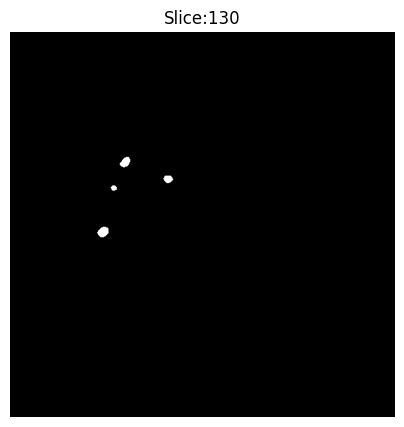

In [7]:
slice = 130
for i in [image, organ_array, lesions]:
    print(i.shape)
    
    plt.figure(figsize=(5,5))
    plt.imshow((np.rot90(i[0, :, :, slice], k=1)), cmap="gray")
    plt.title(f"Slice:{slice}")
    plt.axis("off")

torch.Size([512, 512, 180])


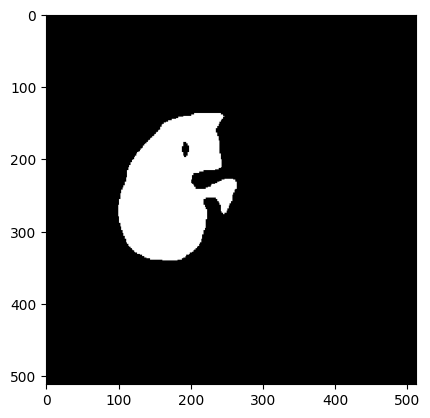

In [8]:
foreground_mask = torch.from_numpy((organ_array.sum(axis=0) > 0).astype(np.float32))
print(foreground_mask.shape)
plt.imshow((np.rot90(foreground_mask[:, :, slice], k=1)), cmap="gray")

In [9]:
mask_nonzero = torch.nonzero(foreground_mask)
if mask_nonzero.numel() == 0:
    # fallback if mask is empty
    zmin, ymin, xmin = 0, 0, 0
    zmax, ymax, xmax = foreground_mask.shape
else:
    zmin, ymin, xmin = mask_nonzero.min(0)[0]
    zmax, ymax, xmax = mask_nonzero.max(0)[0] + 1

In [10]:
margin = 20
zmin, ymin, xmin = max(zmin - margin, 0), max(ymin - margin, 0), max(xmin - margin, 0)
zmax = min(zmax + margin, foreground_mask.shape[0])
ymax = min(ymax + margin, foreground_mask.shape[1])
xmax = min(xmax + margin, foreground_mask.shape[2])

# Crop image, organ_array, lesions
image = image[:, zmin:zmax, ymin:ymax, xmin:xmax]
organ_array = organ_array[:, zmin:zmax, ymin:ymax, xmin:xmax]
if lesions is not None:
    lesions = lesions[:, zmin:zmax, ymin:ymax, xmin:xmax]

In [11]:
print(
    "Image shape:", image.shape,
    "\nOrgan array shape:", organ_array.shape,
    "\nLesions shape:", lesions.shape
)  

Image shape: torch.Size([1, 253, 249, 110]) 
Organ array shape: torch.Size([1, 253, 249, 110]) 
Lesions shape: torch.Size([1, 253, 249, 110])


torch.Size([1, 253, 249, 110])
torch.Size([1, 253, 249, 110])
torch.Size([1, 253, 249, 110])


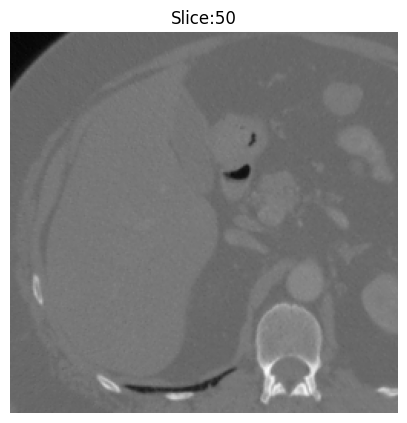

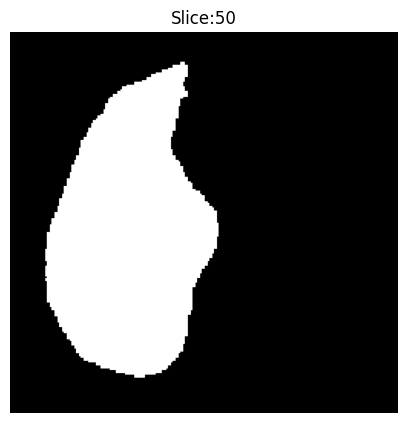

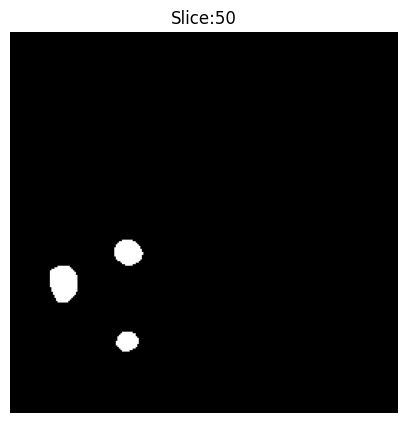

In [14]:
slice = 50
for i in [image, organ_array, lesions]:
    print(i.shape)
    
    plt.figure(figsize=(5,5))
    plt.imshow((np.rot90(i[0, :, :, slice], k=1)), cmap="gray")
    plt.title(f"Slice:{slice}")
    plt.axis("off")

In [52]:
spacing = Spacingd(
                            keys=["image", "mask", "lesions"],
                            pixdim=(1,1,1),
                            mode=("bilinear", "nearest", "nearest"))

In [55]:

data = {"image": image, "mask": organ_array}
if lesions is not None:
    data["lesions"] = lesions

data = spacing(data)

image = data["image"]
organ_array = data["mask"]
lesions = data.get("lesions", None)

print(
    "Image shape:", image.shape,
    "\nOrgan array shape:", organ_array.shape,
    "\nLesions shape:", lesions.shape
)  

: 

In [ ]:
def preprocess_sample(keys, image, organ_array, lesions, label,
                       pixdim=(1,1,1), resize = (128,128,128)):

    spacing_img = Spacing(pixdim=pixdim, mode="nearest")
    intensity_scaler = ScaleIntensityRange(a_min=-100, a_max=300, b_min=0.0, b_max=1.0, clip=True)



    # Ensure channel-first
    if image.ndim == 3:
        image = image.unsqueeze(0)

    # Apply spacing to the image
    image = spacing_img(image)

    # -------- Crop using organ mask --------
    if organ_array is not None:
        # Create single-channel foreground mask
        foreground_mask = torch.from_numpy((organ_array.sum(axis=0) > 0).astype(np.float32))

        # Compute bounding box
        mask_nonzero = torch.nonzero(foreground_mask)
        if mask_nonzero.numel() == 0:
            # fallback if mask is empty
            zmin, ymin, xmin = 0, 0, 0
            zmax, ymax, xmax = foreground_mask.shape
        else:
            zmin, ymin, xmin = mask_nonzero.min(0)[0]
            zmax, ymax, xmax = mask_nonzero.max(0)[0] + 1

        # Optional margin
        margin = 20
        zmin, ymin, xmin = max(zmin - margin, 0), max(ymin - margin, 0), max(xmin - margin, 0)
        zmax = min(zmax + margin, foreground_mask.shape[0])
        ymax = min(ymax + margin, foreground_mask.shape[1])
        xmax = min(xmax + margin, foreground_mask.shape[2])

        # Crop image, organ_array, lesions
        image = image[:, zmin:zmax, ymin:ymax, xmin:xmax]
        organ_array = organ_array[:, zmin:zmax, ymin:ymax, xmin:xmax]
        if lesions is not None:
            lesions = lesions[:, zmin:zmax, ymin:ymax, xmin:xmax]

    # -------- Intensity scaling --------
    image = intensity_scaler(image)

    # -------- 3D Resize (MONAI safe) --------
    # Resize image
    resize_img = Resize(spatial_size=resize, mode='trilinear')
    image = resize_img(image.unsqueeze(0)).squeeze(0)

    # Resize organ_array
    resize_mask = Resize(spatial_size=resize, mode='nearest')
    organ_array = torch.stack([resize_mask(ch.unsqueeze(0)).squeeze(0) for ch in organ_array])

    # Resize lesions if they exist
    if lesions is not None:
        lesions = torch.stack([resize_mask(ch.unsqueeze(0)).squeeze(0) for ch in lesions])

    # -------- Debug print --------
    print(f"Image shape: {image.shape}")
    if organ_array is not None:
        print(f"Organ array shape: {organ_array.shape}")
    if lesions is not None:
        print(f"Lesions shape: {lesions.shape}")

    return image, organ_array, lesions, label

SyntaxError: parameter without a default follows parameter with a default (3140519942.py, line 5)

# Preprocessed Data Loading

In [27]:
folder = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/seg_preprocessed/train"

def load_dataset(folder):
    files = sorted([f for f in os.listdir(folder) if f.endswith(".pt")])

    dataset = []
    i = 0
    while i < min(4, len(files)):
        f = files[i]
        data = torch.load(os.path.join(folder, f))
        dataset.append((data['key'], data["image"], data['organ_array'], data["lesions"], data["label"]))
        i += 1

    return dataset

data = load_dataset(folder)

/tmp/ipykernel_1325898/2749371540.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(folder, f))


In [24]:
len(data)

4

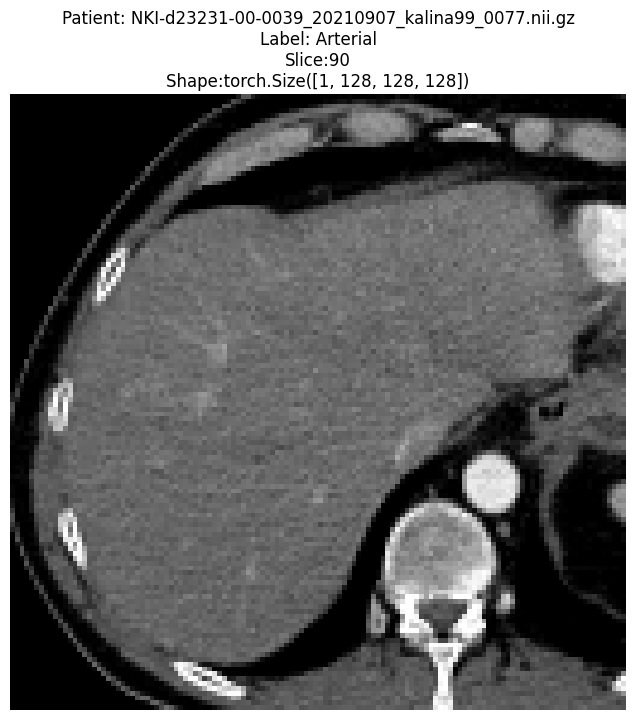

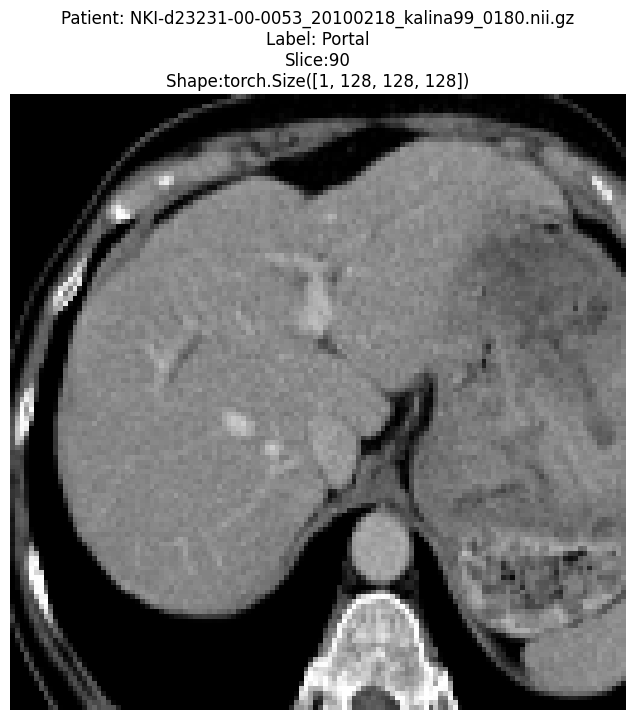

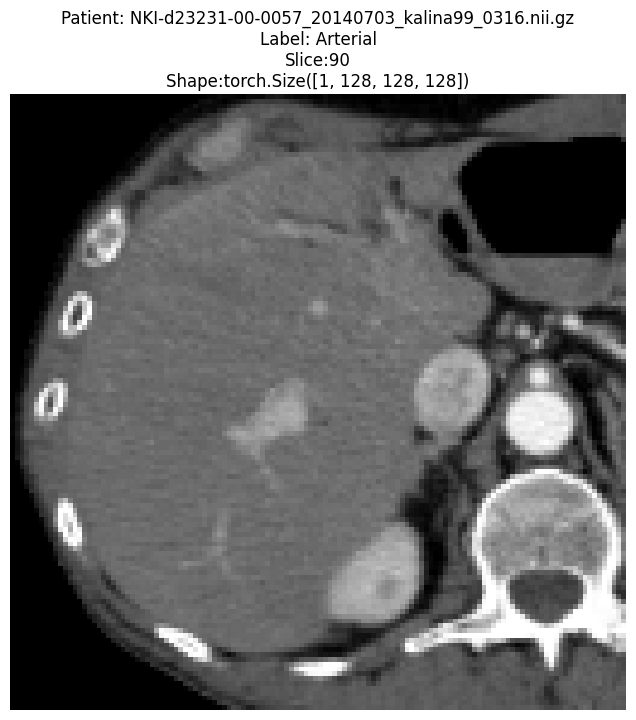

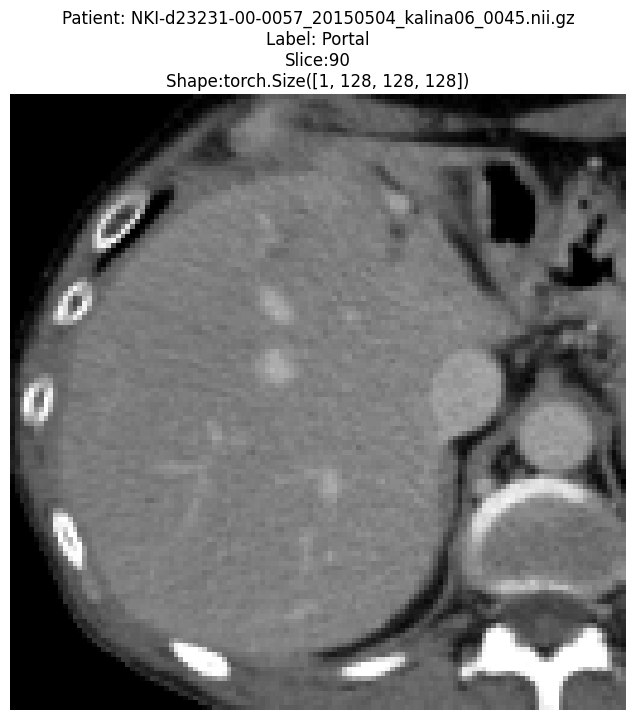

In [28]:
slice = 90

for i in range(len(data)):
    image = data[i][1]
    plt.figure(figsize=(10,8))
    plt.imshow((np.rot90(image[0, :, :, slice], k=1)), cmap="gray")
    plt.title(f"Patient: {data[i][0]}\nLabel: {data[i][4]}\nSlice:{slice}\nShape:{image.shape}")
    plt.axis("off")

In [5]:
from sklearn.preprocessing import LabelEncoder

class SegDataset(Dataset):
    def __init__(self, folder, encoder=None, sample=20, masking=None):
        self.files = sorted([
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.endswith(".pt")
        ])

        self.masking = masking

        if sample:
            self.files = self.files[:sample]

        # Load all labels once
        self.raw_labels = []
        for f in self.files:
            data = torch.load(f)
            self.raw_labels.append(data["label"])

        # Fit encoder once
        if encoder is None:
            self.le = LabelEncoder()
            self.le.fit(self.raw_labels)
        else:
            self.le = encoder

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(self.files[idx])

        image = data["image"]
        organ_mask = data["organ_array"]
        lesion_mask = data["lesions"]
        label = str(data["label"])
        label = self.le.transform([label])[0]
        label = torch.tensor(label, dtype=torch.long)

        if organ_mask is not None and self.masking == "concat":
            image = torch.cat([image, organ_mask], dim=0)
        elif organ_mask is not None and self.masking == "crop":
            image = image * organ_mask
        elif organ_mask is not None and self.masking is None:
            image = image
        else:
            raise ValueError("Invalid masking option or missing organ mask")



        return {
            "input": image,
            "organ_mask": organ_mask,
            "lesion": lesion_mask,
            "label": label
        }

In [6]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

path = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/seg_preprocessed"
train_dataset = SegDataset(f"{path}/train", sample=100)
le = train_dataset.le
val_dataset = SegDataset(f"{path}/val", encoder=le, sample=100)
test_dataset = SegDataset(f"{path}/test", encoder=le, sample=100)

In [112]:
len(train_dataset), len(val_dataset), len(test_dataset)

(100, 79, 95)

In [114]:
train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=5, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=False)

for batch in train_loader:
    images = batch["input"]
    organ_masks = batch["organ_mask"]
    lesion_masks = batch["lesion"]
    labels = batch["label"]
    print("Image shape:", images.shape, 
          "\nOrgan masks shape:", organ_masks.shape,
          "\nLesion masks shape:", lesion_masks.shape,
          "\nLabels:", labels, flush=True)
    break

Image shape: torch.Size([5, 1, 128, 128, 128]) 
Organ masks shape: torch.Size([5, 1, 128, 128, 128]) 
Lesion masks shape: torch.Size([5, 1, 128, 128, 128]) 
Labels: tensor([0, 0, 1, 1, 0])


In [115]:
images[0].shape

torch.Size([1, 128, 128, 128])

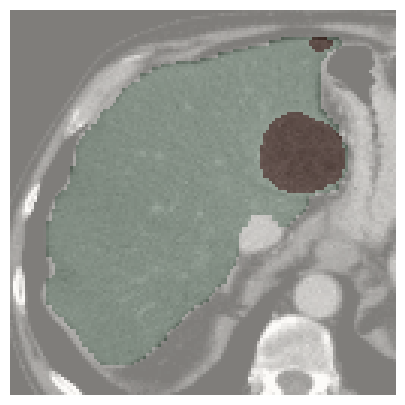

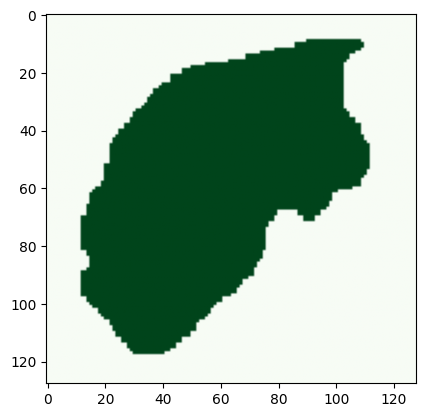

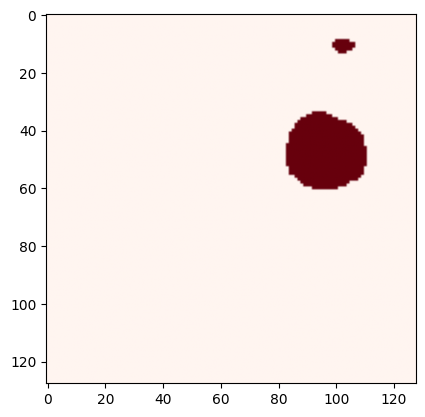

In [52]:
image = images[0]
organ = organ_masks[0]
lesion = lesion_masks[0]
slice_idx = 100

plt.figure(figsize=(10, 5))
plt.imshow(np.rot90(image[0, :, :, slice_idx], k=1), cmap="gray")
plt.imshow(np.rot90(window_ct(organ[0, :, :, slice_idx])), cmap='Greens', alpha=0.3)   # intensity not scaled, just binary

# Overlay lesion mask in red
plt.imshow(np.rot90(window_ct(lesion[0, :, :, slice_idx])), cmap='Reds', alpha=0.3)    # intensity not scaled, jsut binary
plt.axis('off')
plt.show()


plt.imshow(np.rot90(organ[0, :, :, slice_idx]), cmap='Greens') 
plt.show()

plt.imshow(np.rot90(lesion[0, :, :, slice_idx]), cmap='Reds')
plt.show()


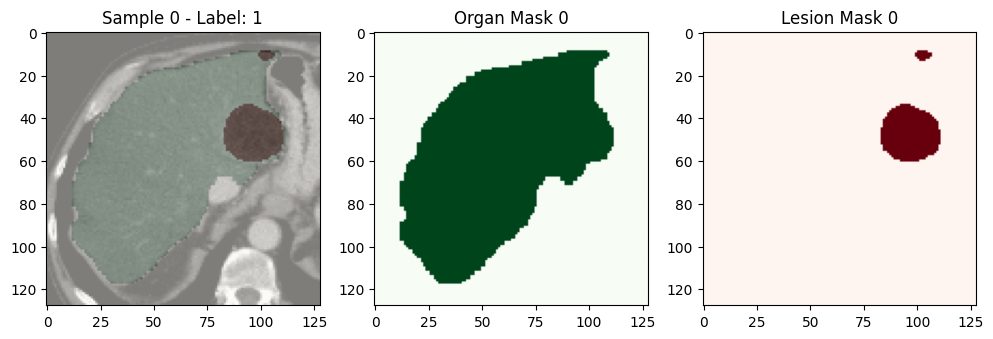

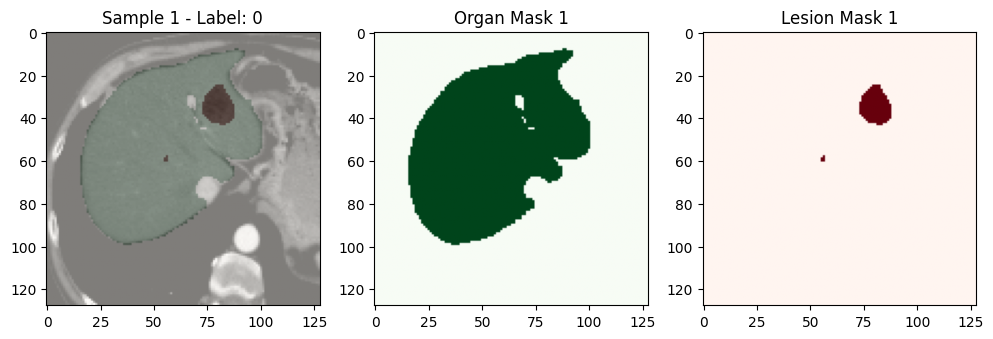

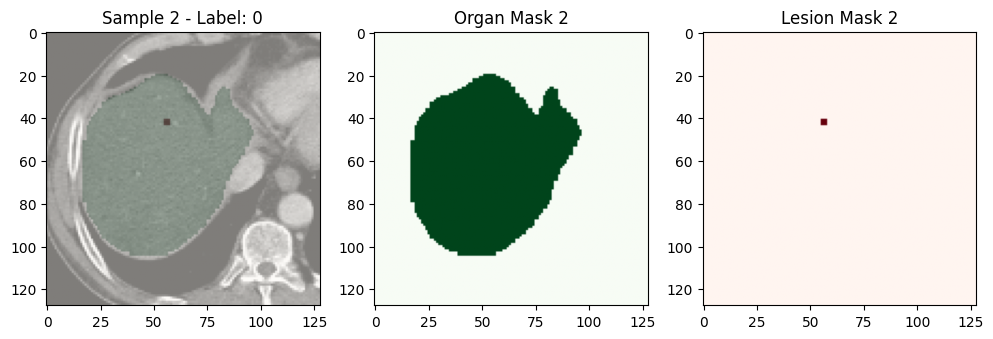

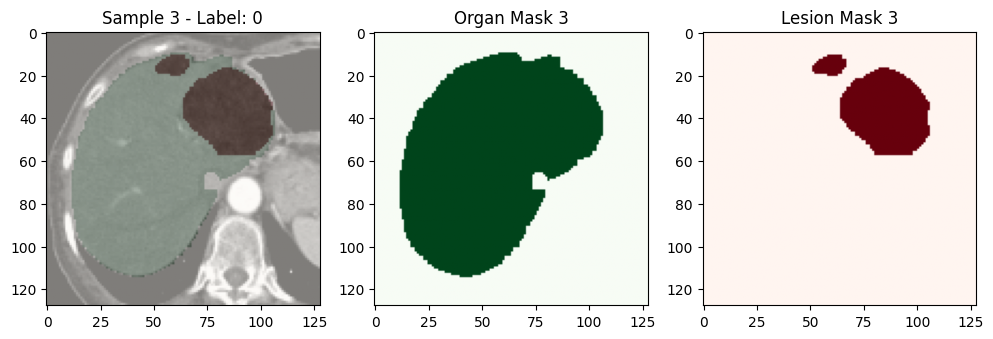

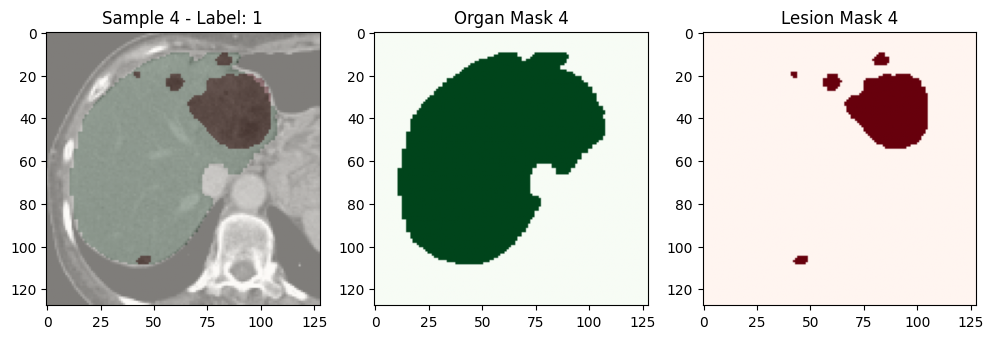

In [ ]:
def plot_slices(batch_idx=0, slice_idx=None):
    img = images[batch_idx]
    organ = organ_masks[batch_idx]
    lesion = lesion_masks[batch_idx]

    # Pick middle slice if not specified
    if slice_idx is None:
        slice_idx = img.shape[0] // 2

    _, axes = plt.subplots(1, 3, figsize=(12, 6))
    axes[0].imshow(np.rot90(img[0, :, :, slice_idx]), cmap='gray')
    axes[0].imshow(window_ct(np.rot90(organ[0, :, :, slice_idx])), cmap='Greens', alpha=0.3)
    axes[0].imshow(window_ct(np.rot90(lesion[0, :, :, slice_idx])), cmap='Reds', alpha=0.3)
    axes[0].set_title(f"Sample {batch_idx} - Label: {labels[batch_idx].item()}")

    
    # Overlay organ mask in green
    axes[1].imshow(window_ct(np.rot90(organ[0, :, :, slice_idx])), cmap='Greens')
    axes[1].set_title(f"Organ Mask {batch_idx}")
    
    # Overlay lesion mask in red
    axes[2].imshow(window_ct(np.rot90(lesion[0, :, :, slice_idx])), cmap='Reds')
    axes[2].set_title(f"Lesion Mask {batch_idx}")
    plt.show()




# Plot all samples in the batch
for i in range(images.shape[0]):
    plot_slices(i, slice_idx=100)

# Single Modality Training Pipe

In [59]:
organ.shape

torch.Size([1, 128, 128, 128])

Possible approaches for incorporating the liver mask as context for the segmentation:
1. Simply concatenate the image and the organ mask along the channel dimension. The network **will learn to predict lesion presence inside the liver**, using the organ mask as extra context.
2. Multiply image by organ mask. The network **will only see the liver and nothing else.** While this approach would reduce the false positives, it might miss lesions or lesion regions that stretch out of the liver, thus, introducing more false negatives.
3. Fusion of 2-stream network, where one branch processes the image and learns to predict the lesion mask solely by the image input and another branch that learn to predict the lesion mask solely based on the liver mask. Fusion depends on a rule that defines the importance of each prediction.

Input shape (concatenated batches): torch.Size([5, 2, 128, 128, 128])


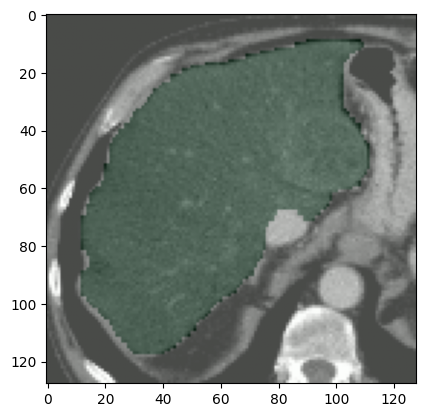

In [ ]:
inputs = torch.cat([images, organ_masks], dim=1)                  # 1st approach
print("Inputs shape (concatenated batches):", inputs.shape)
plt.imshow(np.rot90(inputs[0, 0, :, :, slice_idx]), cmap="gray")  # original image
plt.imshow(np.rot90(inputs[0, 1, :, :, slice_idx]), cmap='Greens', alpha=0.3)  
plt.show()


Inputs shape: torch.Size([5, 1, 128, 128, 128])


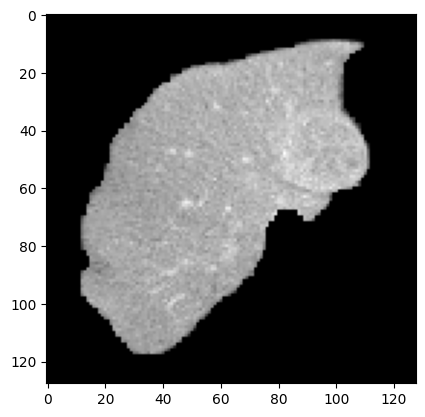

In [ ]:
inputs = images * organ_masks           # 2nd approach: zeros outside liver
print("Inputs shape:", inputs.shape)
plt.imshow(np.rot90(inputs[0, 0, :, :, slice_idx]), cmap="gray") # cropped out image
plt.show()

In segmentation for each input (image or masked image), the model outputs [B, 1, H, W, D] i.e. logits per voxel where each voxel has a value like:
- +3.2 → strong confidence = lesion
- -2.1 → strong confidence = background
- 0.0 → uncertain

The ground truth i.e., the lesion mask also has a shape [B, 1, H, W, D] but each voxel has a binary value (0 or 1) for lesion or background:
- Binary Cross-Entropy Loss (BCE) - predicts the cross-entropy loss per pixel value, while iterating through the image input
- Dice Loss - computes the overlap between the predicted mask and the true mask as a whole

In [7]:
class SegModel(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.encoder = smp.encoders.get_encoder(
            "resnet18",
            in_channels=in_channels,
            depth=5,
            weights=None
        )

        self.decoder = smp.decoders.unet.decoder.UnetDecoder(
            encoder_channels=self.encoder.out_channels,
            decoder_channels=(256, 128, 64, 32, 16),
            n_blocks=5
        )

        self.segmentation_head = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):
        features = self.encoder(x)
        decoder_output = self.decoder(*features)
        masks = self.segmentation_head(decoder_output)
        return masks

In [8]:
from monai.losses import DiceLoss
from monai.metrics import DiceMetric


def train_seg(model, train_loader, val_loader=None, epochs=10, lr=1e-4, weight_decay=1e-4, dice_weight=1.0, bce_weight=1.0):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    bce_loss = torch.nn.BCEWithLogitsLoss()                                                     # binary loss for each pixel (lesion or not) => converts logits to probabilities using sigmoid; stabilizes learning 
    dice_loss = DiceLoss(sigmoid=True)                                                          # overlap loss (1-dice overlap); sigmoid=True => converts logits to probabilities; improves the segmentation quality

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    patience = 3
    counter = 0
    best_model_state = None

    for epoch in range(epochs):
        # ------------------ TRAIN ------------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        dice_metric_train = DiceMetric(include_background=False, reduction="mean")
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)


        for batch in loop:
            images = batch["input"].to(device)
            masks = batch["lesion"].to(device).float()

            optimizer.zero_grad()
            outputs = model(images)                                      # output = logits, e.g., +3.2 → strong confidence lesion; -2.1 → strong confidence background; 0.0 → uncertain

            loss = (dice_weight * dice_loss(outputs, masks) 
                    + bce_weight * bce_loss(outputs, masks))             # combine both losses because class imbalance is high for segmentation (areas without lesions >> areas with lesions)
            
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            loop.set_postfix(loss=loss.item())

            preds = torch.sigmoid(outputs)                               # logits -> probabilities
            preds = (preds > 0.5).float()                                # probabilities -> binary segmentation mask

            train_correct += (preds == masks).sum().item()               # counts how many pixels are correctly predicted and accumulates this number for each batch
            train_total += masks.numel()                                 # accumulates the total number of pixels in the ground truth masks for each batch

            with torch.no_grad():  
                dice_metric_train(preds, masks)                          # accumulates results internally            


        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_correct/ train_total                       # pixel-wise accuracy (not segmentation!)
        train_dice = dice_metric_train.aggregate().item()                # mean dice over all batches - segmentation quality
        dice_metric_train.reset()                                        # reset for the next epoch


        # ---------------- VALIDATION ----------------
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            dice_metric = DiceMetric(include_background=False, reduction="mean")

            with torch.no_grad():
                for batch in val_loader:
                    images = batch["input"].to(device)
                    masks = batch["lesion"].to(device).float()

                    outputs = model(images)
                    loss = (dice_weight * dice_loss(outputs, masks) 
                            + bce_weight * bce_loss(outputs, masks)) 
                    val_loss += loss.item()

                    # Dice score for validation
                    preds = torch.sigmoid(outputs)                               # logits -> probabilities
                    preds = (preds > 0.5).float()                                # probabilities -> binary segmentation mask

                    val_correct += (preds == masks).sum().item()               # counts how many pixels are correctly predicted and accumulates this number for each batch
                    val_total += masks.numel()                                 # accumulates the total number of pixels in the ground truth masks for each batch
                    dice_metric(preds, masks)                                  # accumulates results internally 

            avg_val_loss = val_loss / len(val_loader)
            avg_val_acc = val_correct / val_total               # pixel-wise accuracy
            val_dice = dice_metric.aggregate().item()           # mean dice over all batches - segmentation quality
            dice_metric.reset()                                 # reset for the next epoch

            print(
                f"Epoch {epoch+1}: "
                f"train_loss={avg_train_loss:.4f}, train_pixel_acc={avg_train_acc:.4f} , train_dice={train_dice:.4f} | "
                f"val_loss={avg_val_loss:.4f}, val_pixel_acc={avg_val_acc:.4f}, val_dice={val_dice:.4f}",
                flush=True
            )

            # Early stopping
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                counter = 0
                best_model_state = model.state_dict()
                print("New best model")
            else:
                counter += 1
                print(f"No improvement ({counter}/{patience})")
                if counter >= patience:
                    print("Early stopping triggered")
                    break

    # Load best model weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model

In [9]:
from monai.networks.nets import UNet

In [ ]:

model = UNet(
    spatial_dims=3,
    in_channels=1,   # or 2 if image + liver mask
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2
)
trained_model = train_seg(model, train_loader, val_loader, epochs=5, lr=1e-4, weight_decay=1e-4, dice_weight=3.0, bce_weight=1.0)


Epoch 1: train_loss=3.7735, train_pixel_acc=0.2293 , train_dice=0.0212 | val_loss=3.7198, val_pixel_acc=0.1638, val_dice=0.0295
New best model


Epoch 2: train_loss=3.7277, train_pixel_acc=0.1309 , train_dice=0.0216 | val_loss=3.6952, val_pixel_acc=0.1184, val_dice=0.0290
New best model


Epoch 3: train_loss=3.7087, train_pixel_acc=0.1022 , train_dice=0.0213 | val_loss=3.6810, val_pixel_acc=0.0964, val_dice=0.0287
New best model


Epoch 4: train_loss=3.6972, train_pixel_acc=0.0855 , train_dice=0.0211 | val_loss=3.6729, val_pixel_acc=0.0858, val_dice=0.0284
New best model


Epoch 5: train_loss=3.6905, train_pixel_acc=0.0728 , train_dice=0.0209 | val_loss=3.6672, val_pixel_acc=0.0697, val_dice=0.0283
New best model


## Approach 1: Concatenating

In [119]:
train_dataset = SegDataset(f"{path}/train", sample=100, masking = "concat")
le = train_dataset.le
val_dataset = SegDataset(f"{path}/val", encoder=le, sample=100, masking = "concat")
test_dataset = SegDataset(f"{path}/test", encoder=le, sample=100, masking = "concat")

train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=5, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=False)

for batch in train_loader:
    images = batch["input"]
    organ_masks = batch["organ_mask"]
    lesion_masks = batch["lesion"]
    labels = batch["label"]
    print("Image shape:", images.shape, 
          "\nOrgan masks shape:", organ_masks.shape,
          "\nLesion masks shape:", lesion_masks.shape,
          "\nLabels:", labels, flush=True)
    break

Image shape: torch.Size([5, 2, 128, 128, 128]) 
Organ masks shape: torch.Size([5, 1, 128, 128, 128]) 
Lesion masks shape: torch.Size([5, 1, 128, 128, 128]) 
Labels: tensor([0, 0, 1, 1, 0])


In [120]:
model = UNet(
    spatial_dims=3,
    in_channels=2,   # or 2 if image + liver mask
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2
)
trained_model = train_seg(model, train_loader, val_loader, epochs=5, lr=1e-4, weight_decay=1e-4, dice_weight=3.0, bce_weight=1.0)


Epoch 1: train_loss=3.6708, train_pixel_acc=0.5976 , train_dice=0.0247 | val_loss=3.6296, val_pixel_acc=0.6042, val_dice=0.0342
New best model


Epoch 2: train_loss=3.6432, train_pixel_acc=0.6165 , train_dice=0.0270 | val_loss=3.6173, val_pixel_acc=0.6288, val_dice=0.0350
New best model


Epoch 3: train_loss=3.6336, train_pixel_acc=0.6465 , train_dice=0.0282 | val_loss=3.6100, val_pixel_acc=0.6726, val_dice=0.0387
New best model


Epoch 4: train_loss=3.6275, train_pixel_acc=0.6959 , train_dice=0.0321 | val_loss=3.6054, val_pixel_acc=0.7198, val_dice=0.0431
New best model


Epoch 5: train_loss=3.6236, train_pixel_acc=0.7381 , train_dice=0.0356 | val_loss=3.6023, val_pixel_acc=0.7624, val_dice=0.0472
New best model


## Approach 2: Cropping

In [10]:
train_dataset = SegDataset(f"{path}/train", sample=100, masking = "crop")
le = train_dataset.le
val_dataset = SegDataset(f"{path}/val", encoder=le, sample=100, masking = "crop")
test_dataset = SegDataset(f"{path}/test", encoder=le, sample=100, masking = "crop")

train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=5, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=False)

for batch in train_loader:
    images = batch["input"]
    organ_masks = batch["organ_mask"]
    lesion_masks = batch["lesion"]
    labels = batch["label"]
    print("Image shape:", images.shape, 
          "\nOrgan masks shape:", organ_masks.shape,
          "\nLesion masks shape:", lesion_masks.shape,
          "\nLabels:", labels, flush=True)
    break

Image shape: torch.Size([5, 1, 128, 128, 128]) 
Organ masks shape: torch.Size([5, 1, 128, 128, 128]) 
Lesion masks shape: torch.Size([5, 1, 128, 128, 128]) 
Labels: tensor([0, 0, 0, 0, 1])


In [11]:
model = UNet(
    spatial_dims=3,
    in_channels=1,   # or 2 if image + liver mask
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2
)
trained_model = train_seg(model, train_loader, val_loader, epochs=5, lr=1e-4, weight_decay=1e-4, dice_weight=3.0, bce_weight=1.0)

Epoch 1: train_loss=3.7380, train_pixel_acc=0.6406 , train_dice=0.0347 | val_loss=3.6797, val_pixel_acc=0.7024, val_dice=0.0493
New best model


Epoch 2: train_loss=3.6857, train_pixel_acc=0.7774 , train_dice=0.0545 | val_loss=3.6481, val_pixel_acc=0.8307, val_dice=0.0801
New best model


Epoch 3: train_loss=3.6613, train_pixel_acc=0.8363 , train_dice=0.0698 | val_loss=3.6311, val_pixel_acc=0.8485, val_dice=0.0879
New best model


Epoch 4: train_loss=3.6470, train_pixel_acc=0.8536 , train_dice=0.0757 | val_loss=3.6210, val_pixel_acc=0.8597, val_dice=0.0943
New best model


Epoch 5: train_loss=3.6378, train_pixel_acc=0.8650 , train_dice=0.0809 | val_loss=3.6143, val_pixel_acc=0.8675, val_dice=0.0980
New best model


## Images for the report

In [2]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/Preprocessing/Diffusion_data/full_pairs.csv")
data

,SubjectKeyRadiology,ExamDate,arterial_image,portal_image,arterial_organs,portal_organs,arterial_lesion,portal_lesion,arterial_lesionfree,portal_lesionfree,lesion_visible_both,split,present_phase,output_dir,base_name_raw,dups_count,base_name,output_path
0,NKI-d23231-00-0002,2015-12-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Yes,Yes,True,test,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0002_2015-12-01,0,NKI-d23231-00-0002_2015-12-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
1,NKI-d23231-00-0005,2010-02-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Yes,Yes,True,train,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0005_2010-02-04,0,NKI-d23231-00-0005_2010-02-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
2,NKI-d23231-00-0005,2012-06-18,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Yes,Yes,True,train,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0005_2012-06-18,0,NKI-d23231-00-0005_2012-06-18,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
3,NKI-d23231-00-0005,2022-05-11,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Yes,Yes,True,train,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0005_2022-05-11,0,NKI-d23231-00-0005_2022-05-11,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
4,NKI-d23231-00-0005,2022-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,Yes,Yes,True,train,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0005_2022-10-17,0,NKI-d23231-00-0005_2022-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4505,NKI-d23231-00-0887,2022-02-10,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NaN,NaN,NaN,inference,portal,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0887_2022-02-10,0,NKI-d23231-00-0887_2022-02-10,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
4506,NKI-d23231-00-0887,2022-04-15,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NaN,NaN,NaN,inference,portal,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0887_2022-04-15,0,NKI-d23231-00-0887_2022-04-15,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
4507,NKI-d23231-00-0887,2022-10-28,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NaN,NaN,NaN,inference,portal,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0887_2022-10-28,0,NK

In [5]:
data.iloc[2068:2070, :]

,SubjectKeyRadiology,ExamDate,arterial_image,portal_image,arterial_organs,portal_organs,arterial_lesion,portal_lesion,arterial_lesionfree,portal_lesionfree,lesion_visible_both,split,present_phase,output_dir,base_name_raw,dups_count,base_name,output_path
2068,NKI-d23231-00-0887,2023-08-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,No,No,True,train,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0887_2023-08-30,0,NKI-d23231-00-0887_2023-08-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...
2069,NKI-d23231-00-0888,2022-04-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,No,No,True,val,NaN,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...,NKI-d23231-00-0888_2022-04-20,0,NKI-d23231-00-0888_2022-04-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/cont...


In [10]:
data.iloc[2068, -1]

'/mnt/rhea/data_private/IRBd23-231/GEPNETs/contrast_phase/diffusion_data1/train/NKI-d23231-00-0887_2023-08-30.pt'

In [11]:
sample_path = data.iloc[2068, -1]
scan = torch.load(sample_path)
scan

/tmp/ipykernel_808759/1332133850.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  scan = torch.load(sample_path)


{'patient_id': 'NKI-d23231-00-0887',
 'exam_date': '2023-08-30',
 'arterial_image': metatensor([[[[0.0880, 0.0916, 0.0953,  ..., 0.3800, 0.4936, 0.5880],
           [0.0000, 0.0000, 0.0000,  ..., 0.4685, 0.4559, 0.4471],
           [0.0000, 0.0000, 0.0000,  ..., 0.4098, 0.4065, 0.4013],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0339, 0.0442, 0.0509,  ..., 0.4444, 0.5011, 0.5467],
           [0.0000, 0.0000, 0.0000,  ..., 0.4268, 0.4784, 0.5270],
           [0.0000, 0.0000, 0.0000,  ..., 0.3810, 0.3189, 0.2675],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0000, 0.0000, 0.0000,  ..., 0.4199, 0.4473, 0.4708],
    

In [14]:
scan["arterial_image"].shape

torch.Size([1, 287, 226, 259])

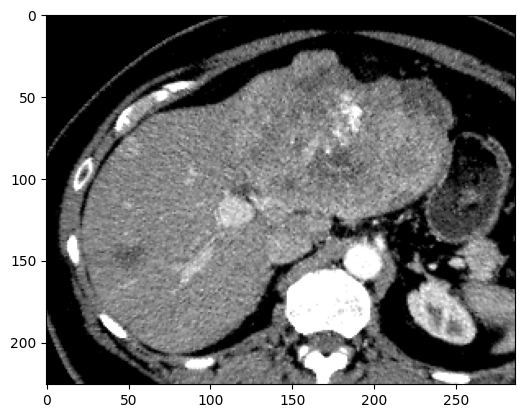

In [37]:
img = scan["arterial_image"][0]
plt.imshow(np.rot90(img[:, :, 150]), cmap="gray")

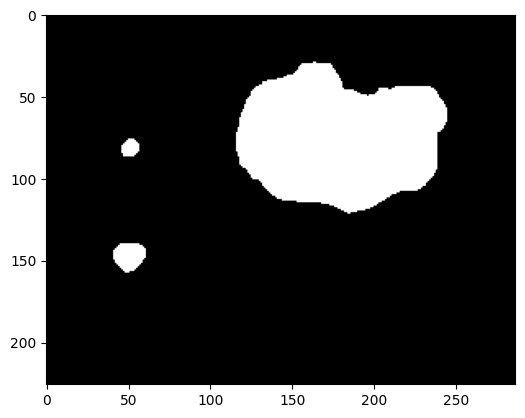

In [40]:
a_lesion = scan["arterial_lesion"][0]
plt.imshow(np.rot90(a_lesion[:, :, 150]), cmap="gray")

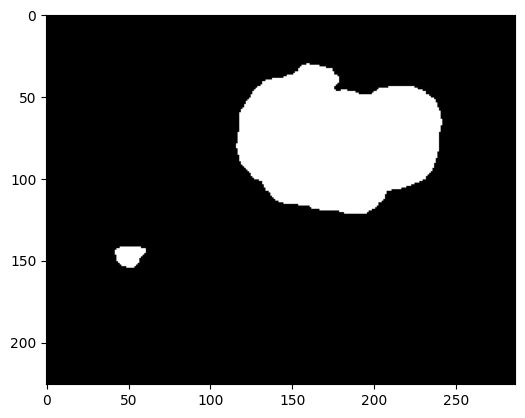

In [41]:
p_lesion = scan["portal_lesion"][0]
plt.imshow(np.rot90(p_lesion[:, :, 150]), cmap="gray")

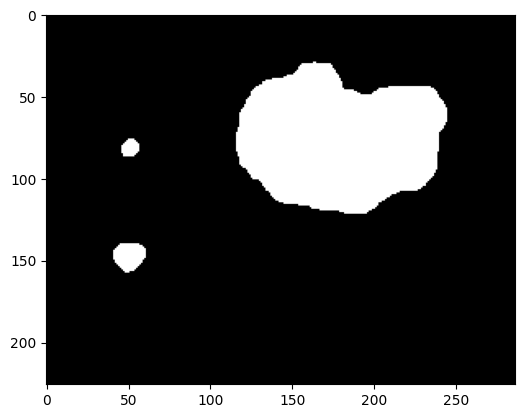

In [44]:
lesion_gt = np.logical_or(a_lesion, p_lesion)
plt.imshow(np.rot90(lesion_gt[:, :, 150]), cmap="gray")

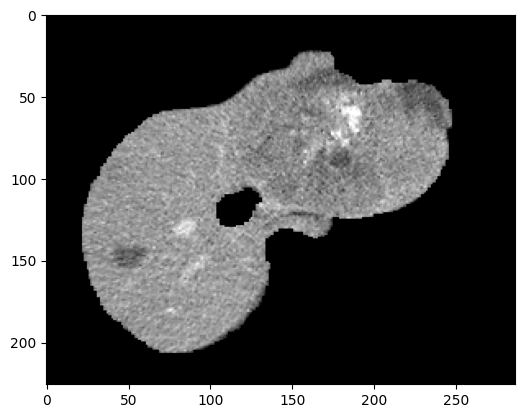

In [36]:
liver = scan["arterial_liver"][0]
input = img * liver
plt.imshow(np.rot90(input[:, :, 150]), cmap="gray")

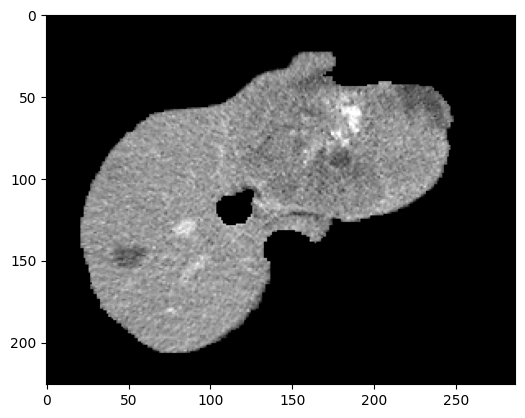

In [35]:
img = scan["portal_image"][0]
liver = scan["portal_liver"][0]
input = img * liver
plt.imshow(np.rot90(input[:, :, 150]), cmap="gray")

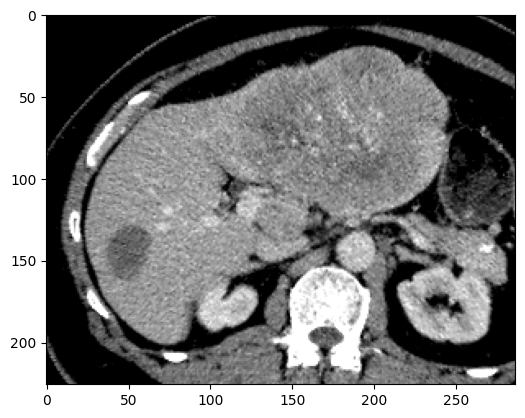

In [34]:
plt.imshow(np.rot90(img[:, :, 135]), cmap="gray")

# Segmentation Quality Evaluation

In [6]:
results = pd.read_csv("/projects/net_contrast_classification/contrast_phase/Segmentation/seg_test_metrics.csv")
results

,SubjectKeyRadiology,ExamDate,Dice,IoU,GT_voxels,Pred_voxels
0,NKI-d23231-00-0010,2007-02-13,0.746071,0.594987,107355.0,164182.0
1,NKI-d23231-00-0012,2009-11-11,0.000000,0.000000,0.0,16431.0
2,NKI-d23231-00-0036_1,2005-12-01,0.003258,0.001631,102.0,45944.0
3,NKI-d23231-00-0043,2005-08-10,0.000000,0.000000,0.0,7773.0
4,NKI-d23231-00-0043,2007-05-01,0.000000,0.000000,0.0,50254.0
...,...,...,...,...,...,...
410,NKI-d23231-00-0872,2022-08-10,0.000000,0.000000,0.0,17715.0
411,NKI-d23231-00-0874,2022-06-10,0.794914,0.659633,46054.0,62091.0
412,NKI-d23231-00-0881,2021-11-05,0.808410,0.678429,120866.0,154764.0
413,NKI-d23231-00-0881,2022-08-17,0.863404,0.759640,141725.0,180115.0


In [7]:
df = results
# --------------------------------------------------
# Basic statistics
# --------------------------------------------------

print("Total test cases:", len(df))


# --------------------------------------------------
# Separate lesion-present and lesion-free cases
# --------------------------------------------------

lesion_cases = df[df["GT_voxels"] > 0].copy()
lesion_free_cases = df[df["GT_voxels"] == 0].copy()


print("\nLesion-present cases:", len(lesion_cases))
print("Lesion-free cases:", len(lesion_free_cases))


# --------------------------------------------------
# Lesion segmentation performance
# --------------------------------------------------

print("\n===== Lesion-present performance =====")

lesion_metrics = lesion_cases[
    ["Dice", "IoU"]
].describe()

print(lesion_metrics)


print("\nMean Dice:", lesion_cases["Dice"].mean())
print("Median Dice:", lesion_cases["Dice"].median())
print("Std Dice:", lesion_cases["Dice"].std())

print("\nMean IoU:", lesion_cases["IoU"].mean())


# --------------------------------------------------
# Successful segmentation rates
# --------------------------------------------------

for threshold in [0.3, 0.5, 0.7]:

    success_rate = (
        (lesion_cases["Dice"] >= threshold).sum()
        /
        len(lesion_cases)
    )

    print(
        f"Dice >= {threshold}: {success_rate*100:.2f}%"
    )


# --------------------------------------------------
# Lesion-free false positives
# --------------------------------------------------

print("\n===== Lesion-free evaluation =====")

false_positive_cases = lesion_free_cases[
    lesion_free_cases["Pred_voxels"] > 0
]


fp_rate = len(false_positive_cases) / len(lesion_free_cases)


print(
    f"False positive cases: {len(false_positive_cases)}/{len(lesion_free_cases)}"
)

print(
    f"False positive rate: {fp_rate*100:.2f}%"
)


print(
    "Mean false positive voxels:",
    lesion_free_cases["Pred_voxels"].mean()
)


# --------------------------------------------------
# Volume agreement
# --------------------------------------------------

lesion_cases["volume_error_%"] = (
    abs(
        lesion_cases["Pred_voxels"]
        -
        lesion_cases["GT_voxels"]
    )
    /
    lesion_cases["GT_voxels"]
    *
    100
)


print("\n===== Volume agreement =====")

print(
    "Mean volume error (%):",
    lesion_cases["volume_error_%"].mean()
)

print(
    "Median volume error (%):",
    lesion_cases["volume_error_%"].median()
)


# --------------------------------------------------
# Worst cases
# --------------------------------------------------

print("\n===== Worst Dice cases =====")

print(
    lesion_cases.sort_values(
        "Dice"
    ).head(10)
)


# --------------------------------------------------
# Best cases
# --------------------------------------------------

print("\n===== Best Dice cases =====")

print(
    lesion_cases.sort_values(
        "Dice",
        ascending=False
    ).head(10)
)


# --------------------------------------------------
# Histograms
# --------------------------------------------------

plt.figure(figsize=(6,4))

plt.hist(
    lesion_cases["Dice"],
    bins=20
)

plt.xlabel("Dice score")
plt.ylabel("Number of cases")
plt.title("Dice distribution - lesion cases")

plt.savefig(
    "dice_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


plt.figure(figsize=(6,4))

plt.scatter(
    lesion_cases["GT_voxels"],
    lesion_cases["Dice"]
)

plt.xlabel("Ground truth lesion volume (voxels)")
plt.ylabel("Dice")

plt.title(
    "Dice versus lesion size"
)

plt.savefig(
    "dice_vs_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

Total test cases: 415

Lesion-present cases: 303
Lesion-free cases: 112

===== Lesion-present performance =====
             Dice         IoU
count  303.000000  303.000000
mean     0.631271    0.508973
std      0.262608    0.253275
min      0.000000    0.000000
25%      0.506224    0.338904
50%      0.716395    0.558111
75%      0.838096    0.721313
max      0.944770    0.895321

Mean Dice: 0.6312707147565624
Median Dice: 0.7163947820663452
Std Dice: 0.2626084591426435

Mean IoU: 0.5089726819779352
Dice >= 0.3: 84.49%
Dice >= 0.5: 75.25%
Dice >= 0.7: 53.80%

===== Lesion-free evaluation =====
False positive cases: 112/112
False positive rate: 100.00%
Mean false positive voxels: 29656.39285714286

===== Volume agreement =====
Mean volume error (%): 1379.442103501213
Median volume error (%): 37.881243327521716

===== Worst Dice cases =====
      SubjectKeyRadiology    ExamDate      Dice       IoU  GT_voxels  \
306    NKI-d23231-00-0449  2009-10-08  0.000000  0.000000      345.0   
165   

In [8]:
print("\n===== Best Dice cases =====")

lesion_cases.sort_values(
        "Dice",
        ascending=False
    ).head(10)



===== Best Dice cases =====


,SubjectKeyRadiology,ExamDate,Dice,IoU,GT_voxels,Pred_voxels,volume_error_%
382,NKI-d23231-00-0742,2017-06-06,0.944770,0.895321,1002301.0,1069719.0,6.726323
62,NKI-d23231-00-0086,2014-12-18,0.943046,0.892231,1286645.0,1300562.0,1.081650
268,NKI-d23231-00-0344,2015-02-20,0.941316,0.889138,2231776.0,2357827.0,5.648013
63,NKI-d23231-00-0086,2015-04-14,0.939669,0.886204,1390945.0,1427578.0,2.633677
67,NKI-d23231-00-0086,2017-01-24,0.939603,0.886087,886644.0,917511.0,3.481330
266,NKI-d23231-00-0344,2014-01-13,0.935898,0.879519,1374545.0,1492829.0,8.605320
66,NKI-d23231-00-0086,2016-04-06,0.933762,0.875755,1064712.0,1056183.0,0.801062
265,NKI-d23231-00-0344,2013-07-04,0.932831,0.874117,1190318.0,1313723.0,10.367398
285,NKI-d23231-00-0407,2010-12-20,0.926111,0.862389,708955.0,769257.0,8.505758
264,NKI-d23231-00-0344,2012-06-11,0.924434,0.859486,1038009.0,1113857.0,7.307066


In [9]:
lesion_cases.sort_values(
        "Dice",
    ).head(10)

,SubjectKeyRadiology,ExamDate,Dice,IoU,GT_voxels,Pred_voxels,volume_error_%
306,NKI-d23231-00-0449,2009-10-08,0.000000,0.000000,345.0,169770.0,49108.695652
165,NKI-d23231-00-0199,2008-09-18,0.000000,0.000000,117.0,13008.0,11017.948718
310,NKI-d23231-00-0461_3,2013-10-30,0.001146,0.000574,1020.0,166466.0,16220.196078
362,NKI-d23231-00-0586,2009-02-04,0.001655,0.000828,390.0,395954.0,101426.666667
409,NKI-d23231-00-0872,2022-01-13,0.002400,0.001202,30.0,24968.0,83126.666667
2,NKI-d23231-00-0036_1,2005-12-01,0.003258,0.001631,102.0,45944.0,44943.137255
238,NKI-d23231-00-0301,2016-04-12,0.008489,0.004262,327.0,61638.0,18749.541284
236,NKI-d23231-00-0301,2015-04-20,0.010292,0.005173,756.0,120886.0,15890.211640
179,NKI-d23231-00-0217,2009-10-19,0.013592,0.006842,1011.0,94928.0,9289.515331
126,NKI-d23231-00-0161_1,2007-11-01,0.017799,0.008979,1905.0,160690.0,8335.170604
